## 1.Environment setup

In [1]:
# ============================================================
# 1. SETUP — FAST, LIGHTWEIGHT, KAGGLE-FRIENDLY
# ============================================================
import os
import re
import gc
import time
import math
import sqlite3
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

# Optional high-performance dataframe engine.
try:
    import polars as pl
    HAS_POLARS = True
except Exception:
    HAS_POLARS = False

# Fast string similarity library. Kaggle commonly has it installed.
try:
    from rapidfuzz import fuzz
    HAS_RAPIDFUZZ = True
except Exception:
    HAS_RAPIDFUZZ = False

print("Environment ready")
print("Polars:", HAS_POLARS)
print("RapidFuzz:", HAS_RAPIDFUZZ)

Environment ready
Polars: True
RapidFuzz: False


## 2. Locate the dataset automatically

Kaggle mounts datasets under `/kaggle/input/<dataset-slug>/`.

We will **search rather than hard-code a single versioned path**, so the notebook remains reusable if the dataset version changes.

The official challenge format uses TSV files. In particular, the ground-truth file contains a Source 1 ID and a comma-separated list of matching Source 2/3 IDs.

In [2]:
import os
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")

# Print all available datasets in /kaggle/input
print("Available datasets in /kaggle/input:")
for item in INPUT_ROOT.iterdir():
    print(" -", item.name)

# Attempt fuzzy match for Amazon datasets or grab the first directory available
dataset_dirs = [p for p in INPUT_ROOT.iterdir() if p.is_dir()]

# Try to find a directory containing 'amazon' or fallback to the first attached dataset
DATA_ROOT = next((p for p in dataset_dirs if "amazon" in p.name.lower()), None)

if DATA_ROOT is None and dataset_dirs:
    DATA_ROOT = dataset_dirs[0]

if DATA_ROOT is None:
    raise FileNotFoundError(
        "No datasets found in /kaggle/input. Ensure you have added the dataset in the right-side panel."
    )

print("\nSelected DATA_ROOT:", DATA_ROOT)

# List all files inside the directory
all_files = sorted(DATA_ROOT.rglob("*"))
for f in all_files:
    if f.is_file():
        print(" -", f.relative_to(DATA_ROOT))

Available datasets in /kaggle/input:
 - datasets

Selected DATA_ROOT: /kaggle/input/datasets
 - abhilashpalit/989-bundle/final_tuned_catboost_v4_depth10_deployment_bundle.joblib
 - satwiksps/amazon-ml-challenge-2026/dataset/test/test_source1.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/test/test_source2.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/test/test_source3.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/train/train_ground_truth.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/train/train_source1.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/train/train_source2.tsv
 - satwiksps/amazon-ml-challenge-2026/dataset/train/train_source3.tsv
 - satwiksps/amazon-ml-challenge-2026/validate_submission.py


## 3. Confirm the challenge file structure

A crucial detail is that these are **tab-separated files**. Reading them as comma-separated CSVs can collapse the entire row into one column.

In [3]:
# ============================================================
# 3. RESOLVE TRAIN / TEST PATHS
# ============================================================
def find_file(filename):
    hits = list(DATA_ROOT.rglob(filename))
    if not hits:
        raise FileNotFoundError(f"Could not find {filename}")
    return hits[0]

FILES = {
    "train_s1": find_file("train_source1.tsv"),
    "train_s2": find_file("train_source2.tsv"),
    "train_s3": find_file("train_source3.tsv"),
    "ground_truth": find_file("train_ground_truth.tsv"),
    "test_s1": find_file("test_source1.tsv"),
    "test_s2": find_file("test_source2.tsv"),
    "test_s3": find_file("test_source3.tsv"),
}

for k, v in FILES.items():
    print(f"{k:14s} -> {v}")

train_s1       -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/train/train_source1.tsv
train_s2       -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/train/train_source2.tsv
train_s3       -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/train/train_source3.tsv
ground_truth   -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/train/train_ground_truth.tsv
test_s1        -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/test/test_source1.tsv
test_s2        -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/test/test_source2.tsv
test_s3        -> /kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/test/test_source3.tsv


## 4. Dataset size — measure first, optimize second

This challenge is genuinely large. A published dataset card reports roughly **26.4 million records across train and test**, so a conventional pandas `read_csv()` of every file is not the best default. citeturn0search2

We therefore use:

- **Polars** when available
- column projection
- small previews for EDA
- sampling for expensive diagnostics
- vectorized normalization
- blocking instead of Cartesian joins

In [4]:
# ============================================================
# 4. FILE SIZES + SMALL PREVIEWS
# ============================================================
for k, path in FILES.items():
    size_mb = path.stat().st_size / (1024**2)
    print(f"{k:14s} {size_mb:10.1f} MB")

def preview_tsv(path, n=5):
    return pd.read_csv(path, sep="\t", nrows=n)

print("\nTRAIN SOURCE 1 PREVIEW")
display(preview_tsv(FILES["train_s1"]))

print("\nGROUND TRUTH PREVIEW")
display(preview_tsv(FILES["ground_truth"]))

train_s1            200.3 MB
train_s2            466.6 MB
train_s3            480.4 MB
ground_truth        121.1 MB
test_s1             166.9 MB
test_s2             485.9 MB
test_s3             482.6 MB

TRAIN SOURCE 1 PREVIEW


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India



GROUND TRUTH PREVIEW


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


## 5. Load only what we need

For this challenge, the core fields are:

- `entity_id`
- `business_name`
- `business_address`
- `country`

The ground truth contains:

- `source1_entity_id`
- `matched_entity_ids`

Keeping the schema narrow reduces memory pressure and makes subsequent operations faster.

In [5]:
# ============================================================
# 5. SCHEMA CHECK
# ============================================================
CORE_COLS = ["entity_id", "business_name", "business_address", "country"]

for name in ["train_s1", "train_s2", "train_s3", "test_s1", "test_s2", "test_s3"]:
    df = pd.read_csv(FILES[name], sep="\t", nrows=3)
    print(f"\n{name}")
    print(df.dtypes)
    print("columns:", list(df.columns))


train_s1
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

train_s2
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

train_s3
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

test_s1
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

test_s2
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address'

## 6. Fast exploratory sample

Full-scale EDA on tens of millions of rows is usually unnecessary.

Instead, we take a reproducible sample from each source and inspect:

- missingness
- country distribution
- text lengths
- duplicate normalized values
- example noise patterns

This gives us useful structural information without turning EDA into the slowest part of the notebook.

In [6]:
# ============================================================
# 6. SAMPLE-BASED EDA
# ============================================================
SAMPLE_N = 50_000
RANDOM_STATE = 42

def sample_tsv(path, n=SAMPLE_N, seed=RANDOM_STATE):
    return pd.read_csv(
        path,
        sep="\t",
        usecols=CORE_COLS,
        nrows=n
    )

eda_s1 = sample_tsv(FILES["train_s1"])
eda_s2 = sample_tsv(FILES["train_s2"])
eda_s3 = sample_tsv(FILES["train_s3"])

for label, df in [("S1", eda_s1), ("S2", eda_s2), ("S3", eda_s3)]:
    print(f"\n===== {label} =====")
    print("rows:", len(df))
    print("missing:")
    display(df.isna().mean().mul(100).round(2).to_frame("missing_%"))
    print("countries:")
    display(df["country"].value_counts(dropna=False).head(15).to_frame("count"))


===== S1 =====
rows: 50000
missing:


,missing_%
entity_id,0.0
business_name,0.0
business_address,0.0
country,0.0


countries:


,count
country,
US,29965
India,20035



===== S2 =====
rows: 50000
missing:


...

,count
country,
US,30097
India,19903



===== S3 =====
rows: 50000
missing:


,missing_%
entity_id,0.00
business_name,0.00
business_address,3.48
country,0.00


countries:


,count
country,
US,29790
India,20210


## 7. Visualize the sample

The following compact dashboard gives us a quick feel for the data.

Because the challenge is entity resolution rather than classical classification, the most useful first plots are:

1. records by country
2. business-name length
3. address length
4. missing-value rates

These are sampled visualizations, not estimates intended to replace the full dataset statistics.

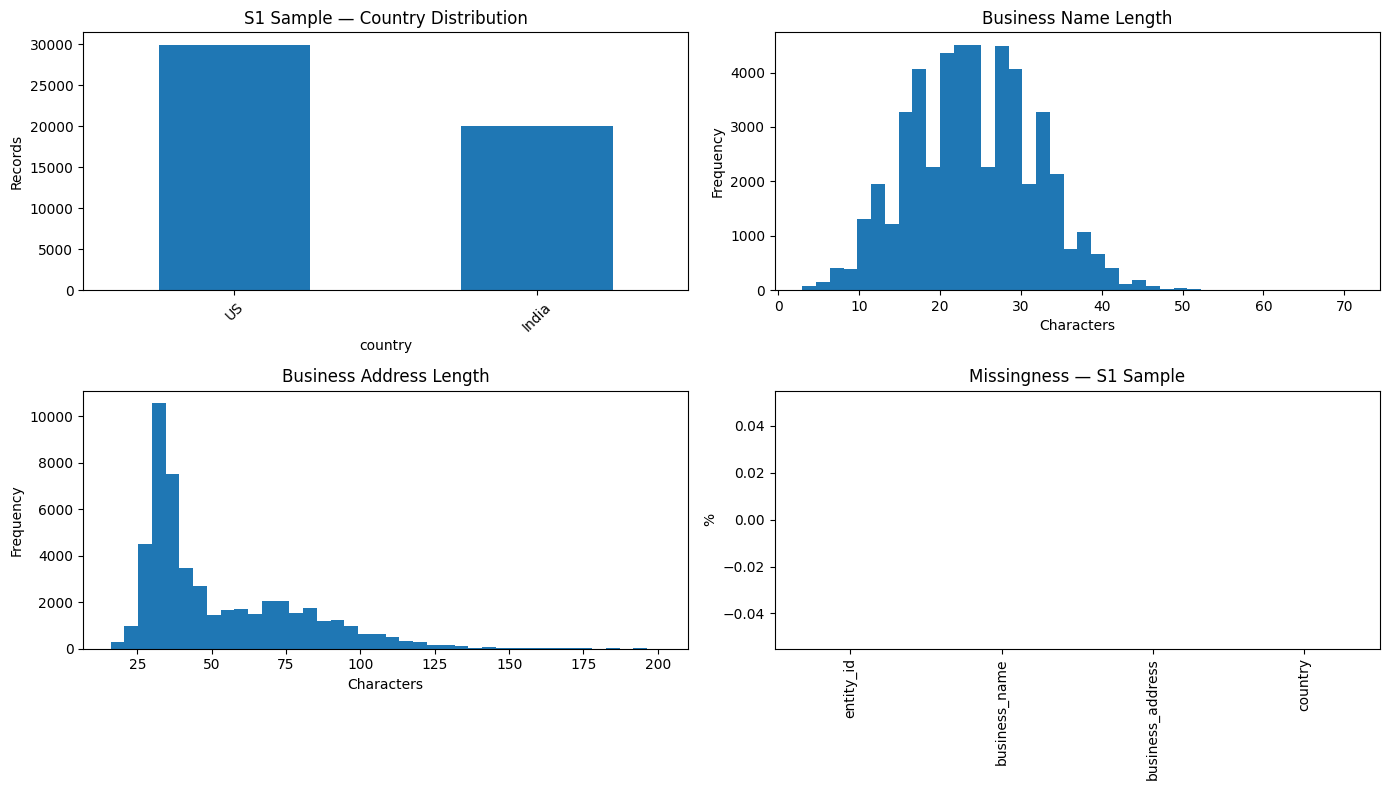

In [7]:
# ============================================================
# 7. QUICK VISUAL DASHBOARD
# ============================================================
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 8))

ax1 = fig.add_subplot(2, 2, 1)
eda_s1["country"].value_counts().head(10).plot(kind="bar", ax=ax1)
ax1.set_title("S1 Sample — Country Distribution")
ax1.set_ylabel("Records")
ax1.tick_params(axis="x", rotation=45)

ax2 = fig.add_subplot(2, 2, 2)
eda_s1["business_name"].fillna("").str.len().clip(upper=100).plot(kind="hist", bins=40, ax=ax2)
ax2.set_title("Business Name Length")
ax2.set_xlabel("Characters")

ax3 = fig.add_subplot(2, 2, 3)
eda_s1["business_address"].fillna("").str.len().clip(upper=250).plot(kind="hist", bins=40, ax=ax3)
ax3.set_title("Business Address Length")
ax3.set_xlabel("Characters")

ax4 = fig.add_subplot(2, 2, 4)
miss = eda_s1.isna().mean().mul(100)
miss.plot(kind="bar", ax=ax4)
ax4.set_title("Missingness — S1 Sample")
ax4.set_ylabel("%")

plt.tight_layout()
plt.show()

## 8. Build robust text normalization

Business names and addresses can differ because of:

- punctuation
- case
- legal suffixes
- `&` versus `and`
- abbreviations
- whitespace
- Unicode variations
- transliteration/noisy formatting

We therefore maintain **multiple representations** instead of destroying information with one aggressive normalization step.

### Representations

- `norm_name`: conservative normalized name
- `compact_name`: whitespace-free normalized name
- `norm_address`: normalized address
- `compact_address`: compact address
- token signatures for blocking

This is especially useful because a single blocking key can create false negatives.

In [8]:
# ============================================================
# 8. NORMALIZATION FUNCTIONS
# ============================================================
LEGAL_SUFFIXES = {
    "incorporated", "inc", "corporation", "corp",
    "limited", "ltd", "llc", "llp",
    "private", "pvt", "company", "co",
    "limitedliabilitycompany"
}

def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = x.replace("&", " and ")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def normalize_name(x):
    s = normalize_text(x)
    tokens = [t for t in s.split() if t not in LEGAL_SUFFIXES]
    return " ".join(tokens)

def normalize_address(x):
    return normalize_text(x)

def compact(s):
    return re.sub(r"\s+", "", s)

def token_signature(s):
    return " ".join(sorted(set(s.split())))

for df in [eda_s1]:
    df["norm_name"] = df["business_name"].map(normalize_name)
    df["norm_address"] = df["business_address"].map(normalize_address)
    df["compact_name"] = df["norm_name"].map(compact)
    df["compact_address"] = df["norm_address"].map(compact)

display(
    eda_s1[
        ["business_name", "norm_name", "business_address", "norm_address"]
    ].head(15)
)

,business_name,norm_name,business_address,norm_address
0,Orelee's Barbershop,orelee s barbershop,"1795 Westchester Drive, High Point, NC",1795 westchester drive high point nc
1,Prime Money,prime money,"17560 Ellis Road, Tahlequah, OK",17560 ellis road tahlequah ok
2,B+ Retail Inc,b retail,"1712 Montebello Avenue, Phoenix, AZ",1712 montebello avenue phoenix az
3,Christ Chapel,christ chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",2100 cameron drive unit apartment g dundalk md
4,Prabhav Business Center,prabhav business center,"797, Lake Town Block A, Kolkata, Howrah, West ...",797 lake town block a kolkata howrah west bengal
5,Custom Wealth Services LLC,custom wealth services,"OH, Columbus, 5559 Orville Avenue",oh columbus 5559 orville avenue
6,Consulting Nyasa Nursing Private Limited,consulting nyasa nursing,"2505, Tower 1, Oakwood, Runwal Greens, Mulund ...",2505 tower 1 oakwood runwal greens mulund gore...
7,Nexus Anchor Rain,nexus anchor rain,"1111 Church Street, Unit 2007, Nashville, TN",1111 church street unit 2007 nashville tn
8,Moore Bitwise Inc,moore bitwise,"337 Oakland Avenue, Michigan City, IN",337 oakland avenue michigan city in
9,Dermatology Green Medicine,dermatology green medicine,"294 Meadowcreek Drive, Unit Unit 2, Village Of...",294 meadowcreek drive unit unit 2 village of p...


## 9. Inspect normalization quality

Normalization should simplify harmless formatting differences without erasing useful identity information.

The table below lets us visually inspect transformations before using them for matching.

If a normalization rule looks too aggressive for your data, modify it here — the rest of the notebook will automatically use the updated functions.

In [9]:
# ============================================================
# 9. NORMALIZATION INSPECTION
# ============================================================
inspection = eda_s1[
    ["business_name", "norm_name", "business_address", "norm_address", "country"]
].copy()

display(inspection.sample(min(25, len(inspection)), random_state=42))

,business_name,norm_name,business_address,norm_address,country
33553,India Devansh Freight Private Limited,india devansh freight,"No.8, 15Th Cross, Davis Road, Near St.Alphonsu...",no 8 15th cross davis road near st alphonsus h...,India
9427,"Gwynne Simpson, DO",gwynne simpson do,"1954 Kresge Drive, Amherst, OH",1954 kresge drive amherst oh,US
199,Kylie's Hair Studio,kylie s hair studio,"15083 County Road 1400, Apache, OK",15083 county road 1400 apache ok,US
12447,4627 Mountain View Street Associates LLC,4627 mountain view street associates,"415 Lower Pigeon Road, Ashcamp, KY",415 lower pigeon road ashcamp ky,US
39489,Grey Montreal PC,grey montreal pc,"Wythe County, 640 Murphyville Road, VA",wythe county 640 murphyville road va,US
42724,Ewing Rocky Launchpad Corp,ewing rocky launchpad,"1654 Desert Oasis Court, Benson, AZ",1654 desert oasis court benson az,US
10822,Tech Marketing Private Limited,tech marketing,"570/472, Virat Nagar, Lucknow, Uttar Pradesh",570 472 virat nagar lucknow uttar pradesh,India
49498,Highland Institute II,highland institute ii,"218 Gold Finch Drive, IA, Corydon",218 gold finch drive ia corydon,US
4144,Complete Arts LLC,complete arts,"3750 Brockport Spencerport Road, Ogden, NY",3750 brockport spencerport road ogden ny,US
36958,Quality Medical Brands LLC,quality medical brands,"Sioux Falls, 1701 Berkshire Boulevard, SD",sioux falls 1701 berkshire boulevard sd,US


## 10. Understand the matching structure

The Source 1 table is the reference side. Source 2 and Source 3 contain noisy records that may correspond to Source 1.

The important consequence is:

> We do **not** need to compare S1 against S1.

We only need candidate links:

```text
S1 → S2
S1 → S3
```

Country is a powerful first-level partition. The published dataset analysis reports that the provided ground truth contains no cross-country matches, while also warning that **France appears in test but not training**. Therefore, we use country as a blocking field but never hard-code the allowed countries.

In [10]:
# ============================================================
# 10. GROUND-TRUTH SUMMARY
# ============================================================
gt = pd.read_csv(FILES["ground_truth"], sep="\t", dtype=str).fillna("")

def split_ids(x):
    if not x:
        return []
    return [v.strip() for v in x.split(",") if v.strip()]

gt["match_list"] = gt["matched_entity_ids"].map(split_ids)
gt["n_matches"] = gt["match_list"].str.len()

print("Ground-truth rows:", len(gt))
print("Singleton / no-match S1:", int((gt["n_matches"] == 0).sum()))
print("S1 with >=1 match:", int((gt["n_matches"] > 0).sum()))
print("Maximum matches for one S1:", int(gt["n_matches"].max()))

display(gt["n_matches"].describe().to_frame("match_count"))

Ground-truth rows: 2206821
Singleton / no-match S1: 123247
S1 with >=1 match: 2083574
Maximum matches for one S1: 11


,match_count
count,2.206821e+06
mean,3.461253e+00
std,1.705323e+00
min,0.000000e+00
25%,2.000000e+00
50%,3.000000e+00
75%,5.000000e+00
max,1.100000e+01


## 11. Learn the match-count distribution

The challenge is not strictly one-to-one.

A Source 1 entity can have:

- no matches
- one match
- several matches

Therefore, a correct pipeline must **not** simply choose the single highest-scoring candidate.

We will score candidates independently and then produce a list for every S1 entity.

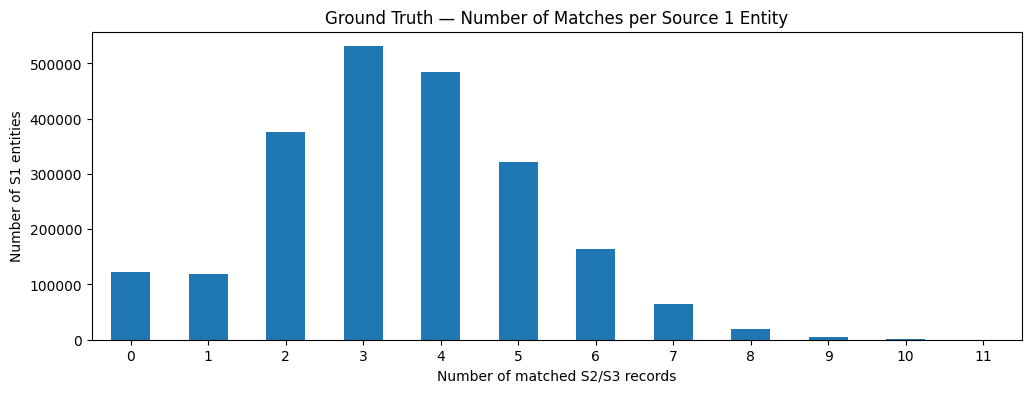

In [11]:
# ============================================================
# 11. MATCH COUNT VISUALIZATION
# ============================================================
counts = gt["n_matches"].value_counts().sort_index()

ax = counts.head(20).plot(kind="bar", figsize=(12, 4))
ax.set_title("Ground Truth — Number of Matches per Source 1 Entity")
ax.set_xlabel("Number of matched S2/S3 records")
ax.set_ylabel("Number of S1 entities")
plt.xticks(rotation=0)
plt.show()

## 12. Exact-match baseline

Before adding fuzzy logic, establish a strong and interpretable baseline.

We test several exact signals:

1. normalized name
2. normalized address
3. normalized name + address
4. compact name + compact address

Exact agreement is particularly valuable in a precision-heavy metric because accidental false merges are expensive.

The official evaluation uses macro-averaged **F₀.₅**, which gives more weight to precision than recall.

In [12]:
# ============================================================
# 12. EXACT MATCH HELPERS
# ============================================================
def prepare_small(df):
    out = df[CORE_COLS].copy()
    out = out.fillna("")
    out["norm_name"] = out["business_name"].map(normalize_name)
    out["norm_address"] = out["business_address"].map(normalize_address)
    out["compact_name"] = out["norm_name"].map(compact)
    out["compact_address"] = out["norm_address"].map(compact)
    out["name_addr_key"] = (
        out["country"].astype(str) + "|" +
        out["compact_name"] + "|" +
        out["compact_address"]
    )
    return out

small_s1 = prepare_small(pd.read_csv(FILES["train_s1"], sep="\t", nrows=20_000, dtype=str))
small_s2 = prepare_small(pd.read_csv(FILES["train_s2"], sep="\t", nrows=50_000, dtype=str))
small_s3 = prepare_small(pd.read_csv(FILES["train_s3"], sep="\t", nrows=50_000, dtype=str))

display(small_s1.head())

,entity_id,business_name,business_address,country,norm_name,norm_address,compact_name,compact_address,name_addr_key
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US,orelee s barbershop,1795 westchester drive high point nc,oreleesbarbershop,1795westchesterdrivehighpointnc,US|oreleesbarbershop|1795westchesterdrivehighp...
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US,prime money,17560 ellis road tahlequah ok,primemoney,17560ellisroadtahlequahok,US|primemoney|17560ellisroadtahlequahok
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US,b retail,1712 montebello avenue phoenix az,bretail,1712montebelloavenuephoenixaz,US|bretail|1712montebelloavenuephoenixaz
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US,christ chapel,2100 cameron drive unit apartment g dundalk md,christchapel,2100camerondriveunitapartmentgdundalkmd,US|christchapel|2100camerondriveunitapartmentg...
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India,prabhav business center,797 lake town block a kolkata howrah west bengal,prabhavbusinesscenter,797laketownblockakolkatahowrahwestbengal,India|prabhavbusinesscenter|797laketownblockak...


## 13. Blocking strategy

A naive comparison would have approximately:

```text
|S1| × (|S2| + |S3|)
```

candidate pairs — far too many.

Instead we generate candidates through several cheap indexes:

### Block A — exact normalized name
`country + compact_name`

### Block B — exact normalized address
`country + compact_address`

### Block C — exact name + address
`country + compact_name + compact_address`

### Block D — token-prefix key
A compact prefix of the strongest name tokens.

The union of these blocks forms the candidate set. The final matcher then applies stricter rules.

In [13]:
# ============================================================
# 13. BLOCKING INDEX
# ============================================================
def build_index(df, column):
    idx = defaultdict(list)
    for row in df.itertuples(index=False):
        key = getattr(row, column)
        if key:
            idx[key].append(row.entity_id)
    return idx

def add_block_keys(df):
    df = df.copy()
    df["country_name_key"] = (
        df["country"].astype(str) + "|" + df["compact_name"]
    )
    df["country_addr_key"] = (
        df["country"].astype(str) + "|" + df["compact_address"]
    )
    df["country_name_addr_key"] = (
        df["country"].astype(str) + "|" +
        df["compact_name"] + "|" + df["compact_address"]
    )
    return df

small_s1 = add_block_keys(small_s1)
small_s2 = add_block_keys(small_s2)
small_s3 = add_block_keys(small_s3)

s2_name_idx = build_index(small_s2, "country_name_key")
s2_addr_idx = build_index(small_s2, "country_addr_key")
s3_name_idx = build_index(small_s3, "country_name_key")
s3_addr_idx = build_index(small_s3, "country_addr_key")

print("S2 name index keys:", len(s2_name_idx))
print("S3 name index keys:", len(s3_name_idx))

S2 name index keys: 44104
S3 name index keys: 45954


## 14. Candidate generation for one entity

For each S1 record, we collect the union of candidates returned by the blocking rules.

This is intentionally transparent: if a true match never enters the candidate set, no later model can recover it.

That is why candidate generation should be treated as a first-class part of entity resolution rather than a preprocessing detail.

In [14]:
# ============================================================
# 14. CANDIDATE GENERATION
# ============================================================
def candidates_for_row(row, indexes):
    candidates = set()

    for key_col, idx in [
        ("country_name_key", indexes["name"]),
        ("country_addr_key", indexes["addr"]),
        ("country_name_addr_key", indexes["name_addr"]),
    ]:
        key = getattr(row, key_col)
        if key:
            candidates.update(idx.get(key, []))

    return candidates

s2_name_addr_idx = build_index(small_s2, "country_name_addr_key")
s3_name_addr_idx = build_index(small_s3, "country_name_addr_key")

INDEXES_S2 = {
    "name": s2_name_idx,
    "addr": s2_addr_idx,
    "name_addr": s2_name_addr_idx,
}
INDEXES_S3 = {
    "name": s3_name_idx,
    "addr": s3_addr_idx,
    "name_addr": s3_name_addr_idx,
}

example = small_s1.iloc[0]
print("Example S1:", example["entity_id"])
print("S2 candidates:", candidates_for_row(example, INDEXES_S2))
print("S3 candidates:", candidates_for_row(example, INDEXES_S3))

Example S1: S1-925783039
S2 candidates: set()
S3 candidates: set()


## 15. Candidate scoring

Candidate generation tells us **who might match**.

Scoring tells us **how strong the evidence is**.

We combine inexpensive signals:

- exact normalized name
- exact normalized address
- compact-name equality
- compact-address equality
- token overlap
- optional RapidFuzz similarity

The final decision is deliberately conservative because the challenge's F₀.₅ metric is precision-heavy.

In [15]:
# ============================================================
# 15. SCORING FUNCTIONS
# ============================================================
def jaccard_tokens(a, b):
    A, B = set(a.split()), set(b.split())
    if not A or not B:
        return 0.0
    return len(A & B) / len(A | B)

def pair_features(a, b):
    name_exact = int(a["compact_name"] != "" and a["compact_name"] == b["compact_name"])
    addr_exact = int(a["compact_address"] != "" and a["compact_address"] == b["compact_address"])
    name_token = jaccard_tokens(a["norm_name"], b["norm_name"])
    addr_token = jaccard_tokens(a["norm_address"], b["norm_address"])

    if HAS_RAPIDFUZZ:
        name_fuzzy = fuzz.token_set_ratio(a["norm_name"], b["norm_name"]) / 100
        addr_fuzzy = fuzz.token_set_ratio(a["norm_address"], b["norm_address"]) / 100
    else:
        name_fuzzy = float(name_exact)
        addr_fuzzy = float(addr_exact)

    return {
        "name_exact": name_exact,
        "addr_exact": addr_exact,
        "name_token": name_token,
        "addr_token": addr_token,
        "name_fuzzy": name_fuzzy,
        "addr_fuzzy": addr_fuzzy,
    }

def match_score(f):
    # Conservative weighting: exact agreement dominates.
    return (
        4.0 * f["name_exact"] +
        4.0 * f["addr_exact"] +
        2.0 * f["name_fuzzy"] +
        2.0 * f["addr_fuzzy"] +
        1.0 * f["name_token"] +
        1.0 * f["addr_token"]
    )

## 16. Inspect individual matches interactively

A good entity-resolution notebook should make errors understandable.

The helper below prints:

- S1 record
- candidate record
- feature values
- total score

This is useful when tuning thresholds or investigating false merges.

In [16]:
# ============================================================
# 16. INTERACTIVE PAIR INSPECTION
# ============================================================
def inspect_pair(a, b):
    f = pair_features(a, b)
    result = pd.DataFrame([{
        "S1": a["entity_id"],
        "candidate": b["entity_id"],
        "country": a["country"],
        "S1_name": a["business_name"],
        "candidate_name": b["business_name"],
        "S1_address": a["business_address"],
        "candidate_address": b["business_address"],
        **f,
        "score": match_score(f)
    }])
    display(result.T)

if len(small_s1) and len(small_s2):
    inspect_pair(small_s1.iloc[0], small_s2.iloc[0])

,0
S1,S1-925783039
candidate,S2-166376419
country,US
S1_name,Orelee's Barbershop
candidate_name,राम मार्केटिंग प्राइवेट लिमिटेड
S1_address,"1795 Westchester Drive, High Point, NC"
candidate_address,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi"
name_exact,0
addr_exact,0
name_token,0.0


## 17. Define the official F₀.₅ evaluation

We reproduce the challenge metric locally.

For each Source 1 entity:

- precision = correct predicted matches / predicted matches
- recall = correct predicted matches / true matches
- F₀.₅ combines them with β = 0.5

Singletons matter: an S1 entity with no true matches should receive an empty prediction.

The challenge computes this per S1 entity and then macro-averages the results.

In [17]:
# ============================================================
# 17. F0.5 METRIC
# ============================================================
def f05_single(true_ids, pred_ids):
    true_set = set(true_ids)
    pred_set = set(pred_ids)

    if not true_set and not pred_set:
        return 1.0
    if not pred_set:
        return 0.0

    tp = len(true_set & pred_set)
    precision = tp / len(pred_set)
    recall = tp / len(true_set) if true_set else 0.0

    if precision == 0 and recall == 0:
        return 0.0

    beta2 = 0.25
    return (1 + beta2) * precision * recall / (beta2 * precision + recall)

def macro_f05(y_true, y_pred):
    return np.mean([
        f05_single(t, p)
        for t, p in zip(y_true, y_pred)
    ])

## 18. Build a validation subset

Full fuzzy validation over millions of records is unnecessary while developing.

We create a reproducible validation slice from the training Source 1 entities and evaluate:

1. strict exact matching
2. conservative multi-signal matching

The goal here is **pipeline diagnosis**, not to claim a leaderboard score from a tiny sample.

In [18]:
# ============================================================
# 18. VALIDATION SUBSET
# ============================================================
VAL_S1_N = 2_000

train_s1_val = pd.read_csv(
    FILES["train_s1"],
    sep="\t",
    usecols=CORE_COLS,
    dtype=str,
    nrows=VAL_S1_N
).fillna("")

train_s2_val = pd.read_csv(
    FILES["train_s2"],
    sep="\t",
    usecols=CORE_COLS,
    dtype=str
).fillna("")

train_s3_val = pd.read_csv(
    FILES["train_s3"],
    sep="\t",
    usecols=CORE_COLS,
    dtype=str
).fillna("")

train_s1_val = add_block_keys(prepare_small(train_s1_val))
train_s2_val = add_block_keys(prepare_small(train_s2_val))
train_s3_val = add_block_keys(prepare_small(train_s3_val))

print("Validation S1:", len(train_s1_val))
print("Validation S2:", len(train_s2_val))
print("Validation S3:", len(train_s3_val))

Validation S1: 2000
Validation S2: 5034616
Validation S3: 5285603


## 19. Create reusable source indexes

The same candidate-generation function can now be used for S2 and S3.

We store records in dictionaries by ID for fast lookup after blocking.

In [ ]:
# ============================================================
# 19. VALIDATION INDEXES
# ============================================================
def make_indexes(df):
    return {
        "name": build_index(df, "country_name_key"),
        "addr": build_index(df, "country_addr_key"),
        "name_addr": build_index(df, "country_name_addr_key"),
    }

val_idx_s2 = make_indexes(train_s2_val)
val_idx_s3 = make_indexes(train_s3_val)

s2_by_id = train_s2_val.set_index("entity_id").to_dict("index")
s3_by_id = train_s3_val.set_index("entity_id").to_dict("index")

## 20. Conservative matcher

Because F₀.₅ is precision-heavy, we use a confidence hierarchy:

### High confidence
- exact normalized name **and** exact normalized address

### Strong partial evidence
- exact normalized name + substantial address similarity
- exact normalized address + substantial name similarity

### Fallback
- high fuzzy agreement on both fields

The threshold is intentionally conservative and should be tuned using the validation score rather than arbitrary leaderboard chasing.

In [ ]:
# ============================================================
# 20. CONSERVATIVE MATCH DECISION
# ============================================================
def is_match(f):
    # Highest-confidence rule
    if f["name_exact"] and f["addr_exact"]:
        return True

    # One exact field + strong support from the other
    if f["name_exact"] and f["addr_fuzzy"] >= 0.90:
        return Trueok 

    if f["addr_exact"] and f["name_fuzzy"] >= 0.92:
        return True

    # Both fields independently strong
    if f["name_fuzzy"] >= 0.96 and f["addr_fuzzy"] >= 0.88:
        return True

    return False

def predict_for_s1(row, idx2, idx3, by_id2, by_id3):
    candidates = set()
    candidates.update(candidates_for_row(row, idx2))
    candidates.update(candidates_for_row(row, idx3))

    predictions = []

    for cid in candidates:
        if cid.startswith("S2-"):
            c = by_id2.get(cid)
        else:
            c = by_id3.get(cid)

        if c is None:
            continue

        f = pair_features(row, c)
        if is_match(f):
            predictions.append(cid)

    return sorted(set(predictions))

## 21. Run validation

This cell evaluates the complete mini-pipeline on the selected validation slice.

We report:

- macro F₀.₅
- number of predicted links
- percentage of singleton predictions
- candidate counts

These diagnostics are more informative than looking at one score alone.

In [ ]:
# ============================================================
# 21. VALIDATION RUN
# ============================================================
gt_lookup = dict(zip(gt["source1_entity_id"], gt["match_list"]))

# Only score IDs that are present in this validation sample.
val_ids = set(train_s1_val["entity_id"])
val_gt = {k: v for k, v in gt_lookup.items() if k in val_ids}

predictions = {}
candidate_counts = []

t0 = time.time()

# Change this line in Section 21:
for _, row in train_s1_val.iterrows():
    pred = predict_for_s1(
        row, val_idx_s2, val_idx_s3, s2_by_id, s3_by_id
    )
    predictions[row["entity_id"]] = pred

elapsed = time.time() - t0

eval_ids = list(val_gt.keys())
y_true = [val_gt[k] for k in eval_ids]
y_pred = [predictions.get(k, []) for k in eval_ids]

score = macro_f05(y_true, y_pred)

print(f"Validation entities: {len(eval_ids):,}")
print(f"Validation time: {elapsed:.2f}s")
print(f"Macro F0.5: {score:.5f}")
print(f"Predicted links: {sum(map(len, y_pred)):,}")
print(f"Predicted singletons: {sum(len(x)==0 for x in y_pred):,}")

## 22. Error analysis

A single metric can hide very different behaviors.

We therefore inspect:

- true positives
- false positives
- false negatives
- singleton decisions
- records with many candidates

This is the section to revisit if the validation score is lower than expected.

In [ ]:
# ============================================================
# 22. ERROR ANALYSIS TABLE
# ============================================================
rows = []

for sid in eval_ids:
    t = set(val_gt[sid])
    p = set(predictions.get(sid, []))

    rows.append({
        "source1_entity_id": sid,
        "true_count": len(t),
        "pred_count": len(p),
        "TP": len(t & p),
        "FP": len(p - t),
        "FN": len(t - p),
        "F0.5": f05_single(t, p)
    })

errors = pd.DataFrame(rows)

display(errors.sort_values(["FP", "FN"], ascending=False).head(25))
print("\nAggregate:")
display(errors[["TP", "FP", "FN", "F0.5"]].sum().to_frame("sum"))

## 23. Threshold sensitivity

Rather than blindly increasing recall, compare several conservative fuzzy thresholds.

This is particularly important here because the challenge explicitly makes precision more valuable than recall.

The best threshold should be selected from your validation evidence and then frozen before generating the final test prediction.

In [ ]:
# ============================================================
# 23. SIMPLE THRESHOLD EXPERIMENT
# ============================================================
def make_rule(name_threshold, addr_threshold):
    def rule(f):
        if f["name_exact"] and f["addr_exact"]:
            return True
        if f["name_exact"] and f["addr_fuzzy"] >= addr_threshold:
            return True
        if f["addr_exact"] and f["name_fuzzy"] >= name_threshold:
            return True
        if f["name_fuzzy"] >= name_threshold and f["addr_fuzzy"] >= addr_threshold:
            return True
        return False
    return rule

threshold_results = []

# Small grid — intentionally cheap.
for nt in [0.92, 0.94, 0.96]:
    for at in [0.84, 0.88, 0.92]:
        rule = make_rule(nt, at)
        preds = {}

        for row in train_s1_val.itertuples(index=False):
            cand = set()
            cand.update(candidates_for_row(row, val_idx_s2))
            cand.update(candidates_for_row(row, val_idx_s3))

            # Convert row namedtuple to dict for pair_features compatibility
            row_dict = row._asdict() if hasattr(row, "_asdict") else row

            out = []
            for cid in cand:
                c = s2_by_id.get(cid) if cid.startswith("S2-") else s3_by_id.get(cid)
                if c is None:
                    continue
                
                # Convert candidate namedtuple/object to dict if needed
                c_dict = c._asdict() if hasattr(c, "_asdict") else c

                if rule(pair_features(row_dict, c_dict)):
                    out.append(cid)
            preds[row.entity_id] = sorted(set(out))

        yp = [preds.get(k, []) for k in eval_ids]
        threshold_results.append({
            "name_threshold": nt,
            "address_threshold": at,
            "macro_F0.5": macro_f05(y_true, yp),
            "predicted_links": sum(map(len, yp))
        })

threshold_df = pd.DataFrame(threshold_results).sort_values(
    "macro_F0.5", ascending=False
)
display(threshold_df)

## 24. Scalable inference design

The full test set is much larger than our validation sample.

For production inference we therefore use a **stream-friendly strategy**:

1. read the test sources
2. normalize only required fields
3. build compact indexes
4. process S1 in chunks
5. generate candidates by blocking
6. score only candidates
7. immediately write results

The key optimization is that fuzzy scoring happens only on blocked candidates — never on the full Cartesian product.

In [ ]:
# ============================================================
# 24. DISK-BACKED TEST DATA CONFIGURATION
# ============================================================

# IMPORTANT:
# The previous full-run attempt died because test_source2.tsv and
# test_source3.tsv were loaded as giant pandas DataFrames before
# inference even started. This version NEVER does that.

FAST_DEV_MODE = False

S1_CHUNK_SIZE = 1_000
PAIR_BATCH_SIZE = 5_000
INDEX_READ_CHUNK = 100_000

INDEX_DB_PATH = Path("/kaggle/working/entity_resolution_test_index.sqlite")

OUTPUT_DIR = Path("/kaggle/working/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("FAST_DEV_MODE:", FAST_DEV_MODE)
print("S1 chunk size:", S1_CHUNK_SIZE)
print("Pair batch size:", PAIR_BATCH_SIZE)
print("Index DB:", INDEX_DB_PATH)


def load_s1_chunked(path, chunksize):
    """Stream Source 1 only. S2/S3 are never loaded into RAM."""
    return pd.read_csv(
        path,
        sep="\t",
        usecols=CORE_COLS,
        dtype=str,
        keep_default_na=False,
        chunksize=chunksize,
    )


# Development mode keeps the same 25k sanity check as before.
# Full mode streams all 878,641 S1 rows.
if FAST_DEV_MODE:
    s1_reader = pd.read_csv(
        FILES["test_s1"],
        sep="\t",
        usecols=CORE_COLS,
        dtype=str,
        keep_default_na=False,
        nrows=25_000,
    )
    S1_STREAM_MODE = False
else:
    s1_reader = load_s1_chunked(
        FILES["test_s1"],
        S1_CHUNK_SIZE,
    )
    S1_STREAM_MODE = True

print("S1 streaming mode:", S1_STREAM_MODE)
print("S2/S3 pandas DataFrames loaded: NO")


## 25. Build a disk-backed Source 2 / Source 3 index

The original `make_indexes()` implementation stores millions of entity IDs in Python dictionaries/lists. That is exactly the kind of structure that can exhaust Kaggle RAM.

We replace only the **storage mechanism**, not the blocking rules:

- country + normalized name
- country + normalized address
- country + normalized name + normalized address

SQLite stores the full test-side records and indexed blocking keys on disk. Candidate generation later queries those indexes in small batches.

The CatBoost model and its 18 features remain completely unchanged.


In [ ]:
# ============================================================
# 25. BUILD DISK-BACKED TEST INDEX
# ============================================================

if INDEX_DB_PATH.exists():
    print("Removing previous index:", INDEX_DB_PATH)
    INDEX_DB_PATH.unlink()

conn = sqlite3.connect(INDEX_DB_PATH)
cur = conn.cursor()

# Speed up bulk construction. The database is an intermediate artifact
# and can be rebuilt from the competition TSVs if necessary.
cur.execute("PRAGMA journal_mode=OFF")
cur.execute("PRAGMA synchronous=OFF")
cur.execute("PRAGMA temp_store=FILE")
cur.execute("PRAGMA cache_size=-262144")  # ~256 MB SQLite page cache

cur.execute("""
CREATE TABLE records (
    entity_id TEXT PRIMARY KEY,
    source INTEGER NOT NULL,
    business_name TEXT NOT NULL,
    business_address TEXT NOT NULL,
    country TEXT NOT NULL,
    country_name_key TEXT NOT NULL,
    country_addr_key TEXT NOT NULL,
    country_name_addr_key TEXT NOT NULL
)
""")

insert_sql = """
INSERT INTO records (
    entity_id, source, business_name, business_address, country,
    country_name_key, country_addr_key, country_name_addr_key
) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
"""


def build_test_index(path, source_number):
    total = 0
    t0 = time.time()

    reader = pd.read_csv(
        path,
        sep="\t",
        usecols=CORE_COLS,
        dtype=str,
        keep_default_na=False,
        chunksize=INDEX_READ_CHUNK,
    )

    for chunk in reader:
        chunk = prepare_small(chunk)
        chunk = add_block_keys(chunk)

        rows = zip(
            chunk["entity_id"],
            chunk["business_name"],
            chunk["business_address"],
            chunk["country"],
            chunk["country_name_key"],
            chunk["country_addr_key"],
            chunk["country_name_addr_key"],
        )

        conn.executemany(
            insert_sql,
            [
                (
                    entity_id,
                    source_number,
                    business_name,
                    business_address,
                    country,
                    country_name_key,
                    country_addr_key,
                    country_name_addr_key,
                )
                for (
                    entity_id,
                    business_name,
                    business_address,
                    country,
                    country_name_key,
                    country_addr_key,
                    country_name_addr_key,
                ) in rows
            ],
        )

        total += len(chunk)
        conn.commit()

        print(
            f"Indexed S{source_number}: {total:,} rows | "
            f"{(time.time() - t0) / 60:.2f} min"
        )

        del chunk
        gc.collect()


print("Building Source 2 disk index...")
build_test_index(FILES["test_s2"], 2)

print("\nBuilding Source 3 disk index...")
build_test_index(FILES["test_s3"], 3)

print("\nCreating blocking indexes...")

cur.execute(
    "CREATE INDEX idx_s2_name ON records(source, country_name_key)"
)
cur.execute(
    "CREATE INDEX idx_s2_addr ON records(source, country_addr_key)"
)
cur.execute(
    "CREATE INDEX idx_s2_name_addr ON records(source, country_name_addr_key)"
)
cur.execute(
    "CREATE INDEX idx_s3_name ON records(source, country_name_key)"
)
cur.execute(
    "CREATE INDEX idx_s3_addr ON records(source, country_addr_key)"
)
cur.execute(
    "CREATE INDEX idx_s3_name_addr ON records(source, country_name_addr_key)"
)

conn.commit()

counts = dict(
    cur.execute(
        "SELECT source, COUNT(*) FROM records GROUP BY source"
    ).fetchall()
)

print("\nDisk-backed index ready:")
print("S2 rows:", counts.get(2, 0))
print("S3 rows:", counts.get(3, 0))
print(
    "Index size:",
    round(INDEX_DB_PATH.stat().st_size / 1024**3, 2),
    "GB",
)


## 26. Candidate generation from the disk-backed index

For each S1 chunk we query the same three blocking keys against S2 and S3.

No full S2/S3 DataFrame and no giant Python blocking dictionary is created.


In [ ]:
# ============================================================
# 26. DISK-BACKED CANDIDATE GENERATION HELPERS
# ============================================================

BLOCK_COLUMNS = {
    "name": "country_name_key",
    "addr": "country_addr_key",
    "name_addr": "country_name_addr_key",
}


def _query_candidates_for_keys(conn, source, column, keys):
    """Return candidate records for <= ~1000 blocking keys."""

    keys = [k for k in keys if k]

    if not keys:
        return []

    placeholders = ",".join("?" for _ in keys)

    sql = f"""
        SELECT entity_id, business_name, business_address, country, {column}
        FROM records
        WHERE source = ?
          AND {column} IN ({placeholders})
    """

    return conn.execute(
        sql,
        [source, *keys],
    ).fetchall()


def candidate_records_for_s1_chunk(s1_chunk, conn):
    """
    Generate the exact same three blocking passes as Mobeen's
    candidate generator, but query the backing index from disk.

    Returns:
        candidate_sets: S1 -> set(candidate IDs)
        pair_records: iterable candidate records, deduplicated
    """

    s1 = prepare_small(s1_chunk)
    s1 = add_block_keys(s1)

    candidate_sets = {
        entity_id: set()
        for entity_id in s1["entity_id"]
    }

    # key -> all S1 IDs sharing that blocking key
    key_maps = {}

    for block_name, column in BLOCK_COLUMNS.items():
        mapping = defaultdict(list)

        for row in s1.itertuples(index=False):
            key = getattr(row, column)
            if key:
                mapping[key].append(row.entity_id)

        key_maps[block_name] = mapping

    seen_pairs = set()
    pair_buffer = []

    def flush_buffer():
        nonlocal pair_buffer
        if pair_buffer:
            out = pair_buffer
            pair_buffer = []
            return out
        return []

    # We yield pair records in manageable groups.
    for block_name, column in BLOCK_COLUMNS.items():

        mapping = key_maps[block_name]
        keys = list(mapping.keys())

        # 1000 S1 rows means comfortably below SQLite's variable limit.
        for start in range(0, len(keys), 1000):

            key_batch = keys[start:start + 1000]

            for source in (2, 3):

                rows = _query_candidates_for_keys(
                    conn,
                    source,
                    column,
                    key_batch,
                )

                for (
                    candidate_id,
                    candidate_name,
                    candidate_address,
                    candidate_country,
                    matched_key,
                ) in rows:

                    for s1_id in mapping.get(matched_key, []):

                        pair_key = (s1_id, candidate_id)

                        if pair_key in seen_pairs:
                            continue

                        seen_pairs.add(pair_key)
                        candidate_sets[s1_id].add(candidate_id)

                        s1_row = s1.loc[
                            s1["entity_id"] == s1_id
                        ].iloc[0]

                        pair_buffer.append({
                            "source1_entity_id": s1_id,
                            "match_id": candidate_id,
                            "s1_name": s1_row["business_name"],
                            "s1_address": s1_row["business_address"],
                            "s1_country": s1_row["country"],
                            "match_name": candidate_name,
                            "match_address": candidate_address,
                            "match_country": candidate_country,
                        })

                        if len(pair_buffer) >= PAIR_BATCH_SIZE:
                            yield candidate_sets, flush_buffer()

    if pair_buffer:
        yield candidate_sets, flush_buffer()

    # Empty chunk still needs a final candidate-set object.
    if not seen_pairs:
        yield candidate_sets, []


print("✓ Disk-backed candidate generator ready.")


In [ ]:
# ============================================================
# 26A. LOAD FROZEN CATBOOST V4 DEPLOYMENT BUNDLE
# ============================================================

import os
import glob
import joblib
import numpy as np
import pandas as pd
import re
import time

BUNDLE_NAME = "final_tuned_catboost_v4_depth10_deployment_bundle.joblib"

bundle_candidates = []

for root in ["/kaggle/input", "/kaggle/working"]:
    if os.path.exists(root):
        bundle_candidates.extend(
            glob.glob(
                os.path.join(root, "**", BUNDLE_NAME),
                recursive=True
            )
        )

if not bundle_candidates:
    raise FileNotFoundError(
        f"Could not find {BUNDLE_NAME} under /kaggle/input or /kaggle/working."
    )

BUNDLE_PATH = bundle_candidates[0]

print("Loading deployment bundle:")
print(BUNDLE_PATH)

deployment_bundle = joblib.load(BUNDLE_PATH)

required_keys = [
    "model",
    "name_vectorizer",
    "address_vectorizer",
    "char_name_vectorizer",
    "char_address_vectorizer",
    "features",
    "threshold",
    "config",
]

missing_keys = [
    key for key in required_keys
    if key not in deployment_bundle
]

if missing_keys:
    raise RuntimeError(
        f"Deployment bundle is missing keys: {missing_keys}"
    )

MODEL = deployment_bundle["model"]

NAME_VECTORIZER = deployment_bundle["name_vectorizer"]
ADDRESS_VECTORIZER = deployment_bundle["address_vectorizer"]
CHAR_NAME_VECTORIZER = deployment_bundle["char_name_vectorizer"]
CHAR_ADDRESS_VECTORIZER = deployment_bundle["char_address_vectorizer"]

MODEL_FEATURES = deployment_bundle["features"]
MODEL_THRESHOLD = float(deployment_bundle["threshold"])

print()
print("=" * 65)
print("CATBOOST V4 DEPLOYMENT BUNDLE LOADED")
print("=" * 65)

print("Model:", deployment_bundle["config"]["model_name"])
print("Features:", len(MODEL_FEATURES))
print("Threshold:", MODEL_THRESHOLD)
print()
print("Feature order:")

for i, feature in enumerate(MODEL_FEATURES, start=1):
    print(f"{i:2d}. {feature}")

if len(MODEL_FEATURES) != 18:
    raise RuntimeError(
        f"Expected 18 features, got {len(MODEL_FEATURES)}"
    )

if MODEL_THRESHOLD != 0.85:
    raise RuntimeError(
        f"Expected frozen threshold 0.85, got {MODEL_THRESHOLD}"
    )

if MODEL.get_feature_importance().shape[0] != 18:
    raise RuntimeError(
        "Loaded CatBoost model does not expect 18 features."
    )

print()
print("✓ 18-feature CatBoost model verified")
print("✓ Threshold = 0.85 verified")
print("✓ Four TF-IDF vectorizers verified")

In [ ]:
!pip install rapidfuzz


In [ ]:
import rapidfuzz

print(f"RapidFuzz version: {rapidfuzz.__version__}")

# Quick test to verify it works
ratio = rapidfuzz.fuzz.ratio("fuzzy string matching", "fuzzy string matching")
print(f"Test match ratio: {ratio}%")


In [ ]:
# ============================================================
# 26B. EXACT V2 FEATURE FUNCTIONS FOR TEST INFERENCE
# ============================================================

from rapidfuzz.fuzz import ratio


def normalize_text(value):
    if value is None:
        return ""

    value = str(value).lower()
    value = re.sub(r"[^a-z0-9\s]", " ", value)
    value = re.sub(r"\s+", " ", value)

    return value.strip()


def normalize_legal_name(value):
    value = normalize_text(value)

    legal_suffixes = [
        "private limited",
        "pvt ltd",
        "pvt limited",
        "private ltd",
        "limited",
        "ltd",
        "llc",
        "incorporated",
        "inc",
        "corp",
        "corporation",
        "company",
        "co",
    ]

    tokens = value.split()

    while tokens:

        removed = False

        for suffix in legal_suffixes:

            suffix_tokens = suffix.split()

            if (
                len(tokens) >= len(suffix_tokens)
                and tokens[-len(suffix_tokens):] == suffix_tokens
            ):
                tokens = tokens[:-len(suffix_tokens)]
                removed = True
                break

        if not removed:
            break

    return " ".join(tokens)


def safe_length_ratio(a, b):

    a = a or ""
    b = b or ""

    if not a or not b:
        return 0.0

    return min(len(a), len(b)) / max(len(a), len(b))


def exact_normalized(a, b):

    a = normalize_text(a)
    b = normalize_text(b)

    if not a or not b:
        return 0

    return int(a == b)


def exact_legal_name(a, b):

    a = normalize_legal_name(a)
    b = normalize_legal_name(b)

    if not a or not b:
        return 0

    return int(a == b)


def token_jaccard(a, b):

    if not a or not b:
        return 0.0

    a = set(str(a).split())
    b = set(str(b).split())

    if not a or not b:
        return 0.0

    return len(a & b) / len(a | b)


def edit_similarity(a, b):

    if not a or not b:
        return 0.0

    return ratio(str(a), str(b)) / 100.0


def rowwise_cosine_similarity(A, B):

    # TfidfVectorizer uses L2 normalization by default.
    # Therefore dot product = cosine similarity.

    return np.asarray(
        A.multiply(B).sum(axis=1)
    ).ravel()

## 27. Score the final candidates

Now we apply the same conservative matching rule used during validation.

Important:

- We never create a match outside the candidate set.
- We preserve every Source 1 entity.
- We allow multiple matches.
- We allow an empty match list.
- We remove duplicates.

In [ ]:
# ============================================================
# 26C. BUILD EXACT 18-FEATURE V4 MATRIX
# ============================================================

def build_v4_features(candidate_pairs):

    """
    candidate_pairs must contain:

        s1_name
        s1_address
        s1_country
        match_name
        match_address
        match_country

    Returns a NumPy matrix with the exact feature order
    stored inside deployment_bundle["features"].
    """

    n = len(candidate_pairs)

    if n == 0:
        return np.empty(
            (0, len(MODEL_FEATURES)),
            dtype=np.float32
        )

    # --------------------------------------------------------
    # Extract text
    # --------------------------------------------------------

    s1_names = (
        candidate_pairs["s1_name"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    match_names = (
        candidate_pairs["match_name"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    s1_addresses = (
        candidate_pairs["s1_address"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    match_addresses = (
        candidate_pairs["match_address"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    s1_countries = (
        candidate_pairs["s1_country"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    match_countries = (
        candidate_pairs["match_country"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    # --------------------------------------------------------
    # V1 + V2 features
    # --------------------------------------------------------

    name_edit = np.array([
        edit_similarity(a, b)
        for a, b in zip(s1_names, match_names)
    ], dtype=np.float32)

    name_jaccard = np.array([
        token_jaccard(a, b)
        for a, b in zip(s1_names, match_names)
    ], dtype=np.float32)

    address_edit = np.array([
        edit_similarity(a, b)
        for a, b in zip(s1_addresses, match_addresses)
    ], dtype=np.float32)

    address_jaccard = np.array([
        token_jaccard(a, b)
        for a, b in zip(s1_addresses, match_addresses)
    ], dtype=np.float32)

    country_match = np.array([
        int(a == b)
        for a, b in zip(s1_countries, match_countries)
    ], dtype=np.float32)

    name_exact_normalized = np.array([
        exact_normalized(a, b)
        for a, b in zip(s1_names, match_names)
    ], dtype=np.float32)

    name_exact_legal = np.array([
        exact_legal_name(a, b)
        for a, b in zip(s1_names, match_names)
    ], dtype=np.float32)

    name_length_ratio = np.array([
        safe_length_ratio(a, b)
        for a, b in zip(s1_names, match_names)
    ], dtype=np.float32)

    address_exact_normalized = np.array([
        exact_normalized(a, b)
        for a, b in zip(s1_addresses, match_addresses)
    ], dtype=np.float32)

    address_length_ratio = np.array([
        safe_length_ratio(a, b)
        for a, b in zip(s1_addresses, match_addresses)
    ], dtype=np.float32)

    s1_name_missing = np.array([
        int(not a.strip())
        for a in s1_names
    ], dtype=np.float32)

    match_name_missing = np.array([
        int(not a.strip())
        for a in match_names
    ], dtype=np.float32)

    s1_address_missing = np.array([
        int(not a.strip())
        for a in s1_addresses
    ], dtype=np.float32)

    match_address_missing = np.array([
        int(not a.strip())
        for a in match_addresses
    ], dtype=np.float32)

    # --------------------------------------------------------
    # WORD TF-IDF
    # EXACT production vectorizers from deployment bundle
    # --------------------------------------------------------

    name_s1_word = NAME_VECTORIZER.transform(
        s1_names
    )

    name_match_word = NAME_VECTORIZER.transform(
        match_names
    )

    address_s1_word = ADDRESS_VECTORIZER.transform(
        s1_addresses
    )

    address_match_word = ADDRESS_VECTORIZER.transform(
        match_addresses
    )

    name_word_cosine = rowwise_cosine_similarity(
        name_s1_word,
        name_match_word
    )

    address_word_cosine = rowwise_cosine_similarity(
        address_s1_word,
        address_match_word
    )

    # --------------------------------------------------------
    # CHARACTER TF-IDF
    # --------------------------------------------------------

    name_s1_char = CHAR_NAME_VECTORIZER.transform(
        s1_names
    )

    name_match_char = CHAR_NAME_VECTORIZER.transform(
        match_names
    )

    address_s1_char = CHAR_ADDRESS_VECTORIZER.transform(
        s1_addresses
    )

    address_match_char = CHAR_ADDRESS_VECTORIZER.transform(
        match_addresses
    )

    name_char_cosine = rowwise_cosine_similarity(
        name_s1_char,
        name_match_char
    )

    address_char_cosine = rowwise_cosine_similarity(
        address_s1_char,
        address_match_char
    )

    # --------------------------------------------------------
    # Assemble exact V4 matrix
    # --------------------------------------------------------

    feature_map = {

        "name_edit_similarity":
            name_edit,

        "name_token_jaccard":
            name_jaccard,

        "address_edit_similarity":
            address_edit,

        "address_token_jaccard":
            address_jaccard,

        "country_match":
            country_match,

        "name_exact_normalized":
            name_exact_normalized,

        "name_exact_legal":
            name_exact_legal,

        "name_length_ratio":
            name_length_ratio,

        "address_exact_normalized":
            address_exact_normalized,

        "address_length_ratio":
            address_length_ratio,

        "s1_name_missing":
            s1_name_missing,

        "match_name_missing":
            match_name_missing,

        "s1_address_missing":
            s1_address_missing,

        "match_address_missing":
            match_address_missing,

        "name_word_tfidf_cosine":
            name_word_cosine,

        "address_word_tfidf_cosine":
            address_word_cosine,

        "name_char_tfidf_cosine":
            name_char_cosine,

        "address_char_tfidf_cosine":
            address_char_cosine,
    }

    # --------------------------------------------------------
    # IMPORTANT:
    # Use bundle feature ordering, not our own ordering.
    # --------------------------------------------------------

    missing = [
        feature
        for feature in MODEL_FEATURES
        if feature not in feature_map
    ]

    if missing:
        raise RuntimeError(
            f"Missing model features: {missing}"
        )

    X = np.column_stack([
        feature_map[feature]
        for feature in MODEL_FEATURES
    ]).astype(np.float32)

    if X.shape != (n, 18):
        raise RuntimeError(
            f"Unexpected feature matrix shape: {X.shape}"
        )

    if not np.isfinite(X).all():
        raise RuntimeError(
            "Non-finite values found in feature matrix."
        )

    return X

In [ ]:
# ============================================================
# 27. MEMORY-SAFE CATBOOST V4 INFERENCE — DISK BACKED
# ============================================================

matching_path = OUTPUT_DIR / "matching_results.tsv"
candidate_path = OUTPUT_DIR / "candidate_pairs.tsv"

for path in [matching_path, candidate_path]:
    if path.exists():
        path.unlink()

print("=" * 70)
print("FINAL CATBOOST V4 DISK-BACKED INFERENCE")
print("=" * 70)
print("Model threshold:", MODEL_THRESHOLD)
print("S1 chunk size:", S1_CHUNK_SIZE)
print("Pair batch size:", PAIR_BATCH_SIZE)
print("S2/S3 in RAM: NO")
print()

total_s1 = 0
total_predicted = 0
total_matched_s1 = 0
total_candidates = 0

t_global = time.time()

# Re-open the index connection for the inference stage.
conn = sqlite3.connect(INDEX_DB_PATH)

if FAST_DEV_MODE:
    s1_reader = pd.read_csv(
        FILES["test_s1"],
        sep="\t",
        usecols=CORE_COLS,
        dtype=str,
        keep_default_na=False,
        nrows=25_000,
        chunksize=S1_CHUNK_SIZE,
    )
else:
    s1_reader = pd.read_csv(
        FILES["test_s1"],
        sep="\t",
        usecols=CORE_COLS,
        dtype=str,
        keep_default_na=False,
        chunksize=S1_CHUNK_SIZE,
    )


def score_pair_buffer(pair_records, matched_by_s1):
    if not pair_records:
        return

    pair_df = pd.DataFrame(pair_records)

    X_batch = build_v4_features(pair_df)
    probabilities = MODEL.predict_proba(X_batch)[:, 1]
    accepted = probabilities >= MODEL_THRESHOLD

    if accepted.any():
        accepted_rows = pair_df.loc[
            accepted,
            ["source1_entity_id", "match_id"],
        ]

        for s1_id, match_id in accepted_rows.itertuples(
            index=False,
            name=None,
        ):
            matched_by_s1.setdefault(s1_id, set()).add(match_id)

    del pair_df
    del X_batch
    del probabilities
    del accepted
    gc.collect()


for s1_chunk in s1_reader:

    chunk_t0 = time.time()
    s1_chunk = s1_chunk.fillna("")

    candidate_sets = {
        entity_id: set()
        for entity_id in s1_chunk["entity_id"]
    }

    matched_by_s1 = {}

    # Deduplicate candidate pairs across the three blocking passes.
    seen_pairs = set()
    pair_buffer = []

    # Build normalized S1 chunk once.
    s1_prepared = add_block_keys(prepare_small(s1_chunk))

    key_maps = {}

    for block_name, column in BLOCK_COLUMNS.items():
        mapping = defaultdict(list)
        for row in s1_prepared.itertuples(index=False):
            key = getattr(row, column)
            if key:
                mapping[key].append(row.entity_id)
        key_maps[block_name] = mapping

    s1_lookup = s1_prepared.set_index("entity_id")[
        ["business_name", "business_address", "country"]
    ].to_dict("index")

    # --------------------------------------------------------
    # Exact Mobeen blocking logic, queried from disk.
    # --------------------------------------------------------
    for block_name, column in BLOCK_COLUMNS.items():

        mapping = key_maps[block_name]
        keys = list(mapping.keys())

        for key_start in range(0, len(keys), 1000):

            key_batch = keys[key_start:key_start + 1000]

            placeholders = ",".join("?" for _ in key_batch)

            for source in (2, 3):

                query = f"""
                    SELECT entity_id, business_name, business_address, country, {column}
                    FROM records
                    WHERE source = ?
                      AND {column} IN ({placeholders})
                """

                rows = conn.execute(
                    query,
                    [source, *key_batch],
                ).fetchall()

                for (
                    candidate_id,
                    candidate_name,
                    candidate_address,
                    candidate_country,
                    matched_key,
                ) in rows:

                    for s1_id in mapping.get(matched_key, []):

                        pair_key = (s1_id, candidate_id)

                        if pair_key in seen_pairs:
                            continue

                        seen_pairs.add(pair_key)
                        candidate_sets[s1_id].add(candidate_id)
                        total_candidates += 1

                        s1_values = s1_lookup[s1_id]

                        pair_buffer.append({
                            "source1_entity_id": s1_id,
                            "match_id": candidate_id,
                            "s1_name": s1_values["business_name"],
                            "s1_address": s1_values["business_address"],
                            "s1_country": s1_values["country"],
                            "match_name": candidate_name,
                            "match_address": candidate_address,
                            "match_country": candidate_country,
                        })

                        if len(pair_buffer) >= PAIR_BATCH_SIZE:
                            score_pair_buffer(
                                pair_buffer,
                                matched_by_s1,
                            )
                            pair_buffer.clear()

    if pair_buffer:
        score_pair_buffer(
            pair_buffer,
            matched_by_s1,
        )
        pair_buffer.clear()

    # --------------------------------------------------------
    # Write exactly one row per S1 in this chunk.
    # --------------------------------------------------------
    matching_rows = []
    candidate_rows = []

    for s1_id in s1_chunk["entity_id"]:

        matches = sorted(
            matched_by_s1.get(s1_id, set())
        )

        candidates = sorted(
            candidate_sets.get(s1_id, set())
        )

        matching_rows.append({
            "source1_entity_id": s1_id,
            "matched_entity_ids": ",".join(matches),
        })

        candidate_rows.append({
            "source1_entity_id": s1_id,
            "candidate_entity_ids": ",".join(candidates),
        })

        if matches:
            total_matched_s1 += 1
            total_predicted += len(matches)

    matching_chunk = pd.DataFrame(matching_rows)
    candidate_chunk = pd.DataFrame(candidate_rows)

    matching_chunk.to_csv(
        matching_path,
        sep="\t",
        index=False,
        mode="a",
        header=not matching_path.exists(),
    )

    candidate_chunk.to_csv(
        candidate_path,
        sep="\t",
        index=False,
        mode="a",
        header=not candidate_path.exists(),
    )

    total_s1 += len(s1_chunk)

    elapsed = time.time() - t_global

    print(
        f"Processed {total_s1:,} S1 | "
        f"Chunk: {(time.time() - chunk_t0):.2f}s | "
        f"Elapsed: {elapsed / 60:.2f} min | "
        f"Candidates: {total_candidates:,} | "
        f"Predicted links: {total_predicted:,}"
    )

    del s1_chunk
    del s1_prepared
    del key_maps
    del s1_lookup
    del candidate_sets
    del matched_by_s1
    del seen_pairs
    del matching_rows
    del candidate_rows
    del matching_chunk
    del candidate_chunk
    del pair_buffer
    gc.collect()

conn.close()

print()
print("=" * 70)
print("CATBOOST V4 INFERENCE COMPLETE")
print("=" * 70)
print("S1 rows processed:", total_s1)
print("S1s with >=1 match:", total_matched_s1)
print("Total candidates:", total_candidates)
print("Total predicted matches:", total_predicted)
print("Inference time:", round((time.time() - t_global) / 60, 2), "minutes")
print("Saved:", matching_path)
print("Saved:", candidate_path)


## 28. Validate the output structure before saving

The challenge requires:

- exactly one row for every test Source 1 entity
- only S2/S3 IDs in match lists
- no duplicate IDs
- empty lists for predicted singletons
- matching IDs must also occur in the candidate file

The full outputs are written incrementally to disk, so validation is also streaming and does not load the complete files into RAM.


In [ ]:
# ============================================================
# 28. STREAMING OUTPUT VALIDATION
# ============================================================

def validate_saved_outputs(
    matching_path,
    candidate_path,
    expected_s1_path,
    expected_limit=None,
    chunk_size=10_000,
):

    problems = []
    matching_rows = 0
    candidate_rows = 0
    matching_links = 0
    expected_position = 0

    expected_reader = pd.read_csv(
        expected_s1_path,
        sep="\t",
        usecols=["entity_id"],
        dtype=str,
        keep_default_na=False,
        chunksize=chunk_size,
        nrows=expected_limit,
    )

    matching_reader = pd.read_csv(
        matching_path,
        sep="\t",
        dtype=str,
        keep_default_na=False,
        chunksize=chunk_size,
    )

    candidate_reader = pd.read_csv(
        candidate_path,
        sep="\t",
        dtype=str,
        keep_default_na=False,
        chunksize=chunk_size,
    )

    for expected_chunk, match_chunk, candidate_chunk in zip(
        expected_reader,
        matching_reader,
        candidate_reader,
    ):

        if len(match_chunk) != len(candidate_chunk):
            problems.append("Matching/candidate chunk sizes differ.")
            break

        expected_ids = expected_chunk["entity_id"].tolist()
        actual_ids = match_chunk["source1_entity_id"].tolist()
        candidate_ids = candidate_chunk["source1_entity_id"].tolist()

        if actual_ids != expected_ids:
            problems.append(
                f"Matching S1 order mismatch near row {expected_position:,}."
            )
            break

        if candidate_ids != expected_ids:
            problems.append(
                f"Candidate S1 order mismatch near row {expected_position:,}."
            )
            break

        expected_position += len(expected_chunk)
        matching_rows += len(match_chunk)
        candidate_rows += len(candidate_chunk)

        for match_row, candidate_row in zip(
            match_chunk.itertuples(index=False),
            candidate_chunk.itertuples(index=False),
        ):

            raw_matches = (
                match_row.matched_entity_ids.split(",")
                if match_row.matched_entity_ids
                else []
            )

            if len(raw_matches) != len(set(raw_matches)):
                problems.append(
                    f"Duplicate match IDs: {match_row.source1_entity_id}"
                )
                break

            bad_prefix = [
                mid for mid in raw_matches
                if not (mid.startswith("S2-") or mid.startswith("S3-"))
            ]

            if bad_prefix:
                problems.append(
                    f"Invalid match ID prefix: {bad_prefix[:3]}"
                )
                break

            candidate_set = (
                set(candidate_row.candidate_entity_ids.split(","))
                if candidate_row.candidate_entity_ids
                else set()
            )

            if not set(raw_matches).issubset(candidate_set):
                problems.append(
                    f"Match outside candidate set: {match_row.source1_entity_id}"
                )
                break

            matching_links += len(raw_matches)

        if problems:
            break

    # Ensure there are no extra output rows beyond expected S1.
    if not problems and expected_position == matching_rows:
        try:
            extra_match = next(matching_reader)
            problems.append("matching_results.tsv contains extra rows.")
        except StopIteration:
            pass

        try:
            extra_candidate = next(candidate_reader)
            problems.append("candidate_pairs.tsv contains extra rows.")
        except StopIteration:
            pass

    if problems:
        print("❌ STREAMING VALIDATION FAILED")
        for problem in problems[:25]:
            print("-", problem)
        return False

    print("=" * 70)
    print("✅ STREAMING VALIDATION PASSED")
    print("=" * 70)
    print("Matching rows:", matching_rows)
    print("Candidate rows:", candidate_rows)
    print("Unique/ordered S1 coverage:", expected_position)
    print("Total predicted links:", matching_links)

    return True


validate_saved_outputs(
    matching_path,
    candidate_path,
    FILES["test_s1"],
    expected_limit=25_000 if FAST_DEV_MODE else None,
)


## 29. Write the required TSV outputs

The two files are written **incrementally during CatBoost inference**:

### `matching_results.tsv`

The leaderboard-scored prediction file.

### `candidate_pairs.tsv`

The final candidate set fed to the matching stage.

This section only checks the files. It does not rebuild them from giant in-memory DataFrames.


In [ ]:
# ============================================================
# 29. OUTPUT FILE CHECK
# ============================================================

print("=" * 70)
print("OUTPUT FILES")
print("=" * 70)

print("matching_results.tsv exists:", matching_path.exists())
print("candidate_pairs.tsv exists :", candidate_path.exists())

if matching_path.exists():
    print(
        "matching_results.tsv size:",
        round(
            matching_path.stat().st_size / 1024**2,
            2,
        ),
        "MB",
    )

if candidate_path.exists():
    print(
        "candidate_pairs.tsv size:",
        round(
            candidate_path.stat().st_size / 1024**2,
            2,
        ),
        "MB",
    )

print()
print("These files were written incrementally during inference.")
print("No full-size matching_df/candidate_df is required.")


## 30. Final prediction diagnostics

Diagnostics are computed by streaming the saved TSVs in chunks.

This avoids recreating the memory-heavy full `matching_df` and `candidate_df` objects that caused the full-run kernel failure.


In [ ]:
# ============================================================
# 30. STREAMING FINAL DIAGNOSTICS
# ============================================================

total_s1_d = 0
total_links_d = 0
zero_match_s1_d = 0
max_matches_d = 0

total_candidates_d = 0
max_candidates_d = 0

matching_reader = pd.read_csv(
    matching_path,
    sep="\t",
    dtype=str,
    keep_default_na=False,
    chunksize=10_000,
)

candidate_reader = pd.read_csv(
    candidate_path,
    sep="\t",
    dtype=str,
    keep_default_na=False,
    chunksize=10_000,
)

for match_chunk, candidate_chunk in zip(
    matching_reader,
    candidate_reader,
):

    match_counts_chunk = match_chunk[
        "matched_entity_ids"
    ].map(
        lambda x: len(x.split(",")) if x else 0
    )

    candidate_counts_chunk = candidate_chunk[
        "candidate_entity_ids"
    ].map(
        lambda x: len(x.split(",")) if x else 0
    )

    total_s1_d += len(match_chunk)

    total_links_d += int(
        match_counts_chunk.sum()
    )

    zero_match_s1_d += int(
        (match_counts_chunk == 0).sum()
    )

    max_matches_d = max(
        max_matches_d,
        int(match_counts_chunk.max()),
    )

    total_candidates_d += int(
        candidate_counts_chunk.sum()
    )

    max_candidates_d = max(
        max_candidates_d,
        int(candidate_counts_chunk.max()),
    )


diagnostics = pd.Series({
    "S1 entities": total_s1_d,
    "Predicted links": total_links_d,
    "Predicted singleton S1": zero_match_s1_d,
    "Singleton rate %": round(
        zero_match_s1_d / total_s1_d * 100,
        2,
    ),
    "Average matches / S1": round(
        total_links_d / total_s1_d,
        4,
    ),
    "Maximum matches / S1": max_matches_d,
    "Total candidates": total_candidates_d,
    "Average candidates / S1": round(
        total_candidates_d / total_s1_d,
        4,
    ),
    "Maximum candidates / S1": max_candidates_d,
})

display(
    diagnostics.to_frame("value")
)


## 31. Inspect the highest-match entities

Multiple matches are valid in this challenge, but unusually large match lists deserve inspection.

The audit below reads `matching_results.tsv` in chunks rather than keeping the complete prediction table in memory.


In [ ]:
# ============================================================
# 31. MULTI-MATCH AUDIT
# ============================================================

multi_match_rows = []

reader = pd.read_csv(
    matching_path,
    sep="\t",
    dtype=str,
    keep_default_na=False,
    chunksize=10_000,
)

for chunk in reader:

    chunk["match_count"] = chunk[
        "matched_entity_ids"
    ].map(
        lambda x: len(x.split(",")) if x else 0
    )

    multi = chunk[
        chunk["match_count"] > 1
    ]

    if len(multi):
        multi_match_rows.append(multi)


if multi_match_rows:

    audit = pd.concat(
        multi_match_rows,
        ignore_index=True,
    )

    display(
        audit.sort_values(
            "match_count",
            ascending=False,
        ).head(30)
    )

    del audit
    del multi_match_rows
    gc.collect()

else:

    print("No multi-match S1 entities.")


##  32. What this pipeline is doing well

### Strengths

- **Fast:** avoids all-pairs comparisons
- **Auditable:** every match has deterministic feature evidence
- **Precision-aware:** conservative decision rules
- **Open-set country handling:** France is not hard-coded
- **Multi-match aware:** one S1 can receive multiple S2/S3 matches
- **Submission-safe:** matches are restricted to generated candidates
- **Lightweight:** no large language model or external API is required

### Important limitation

This is a strong, interpretable baseline rather than a claim of optimal leaderboard performance.

For further improvement, the natural next step is to train a pairwise classifier on blocked candidate pairs using features such as:

- character n-gram similarity
- token-set similarity
- address-number agreement
- postal-code agreement
- token overlap
- country equality
- exact/partial field indicators

## 33. Optional upgrade path

If you want to push this notebook beyond the deterministic baseline, add the following in stages:

**Stage 1 — Better blocking**
- character prefixes
- rare-token inverted indexes
- address-number blocks
- postal-code blocks
- multiple blocking passes

**Stage 2 — Pairwise ML**
- generate positive pairs from ground truth
- generate hard negatives from the same blocks
- train LightGBM / XGBoost / Logistic Regression
- calibrate probabilities

**Stage 3 — Precision control**
- optimize threshold directly for macro F₀.₅
- add singleton confidence rules
- analyze false-merge clusters

**Stage 4 — Scale**
- Polars lazy execution
- chunked S1 inference
- compact integer IDs
- Parquet intermediates
- parallel candidate scoring

The challenge documentation emphasizes that blocking determines the recall ceiling, while the final matching model decides which candidates become actual links.

## 34. Challenge-aware checklist

Before submitting:

- [ ] Read all TSV files with `sep="\t"`
- [ ] Do not hard-code countries to only US/India
- [ ] Include every test S1 entity
- [ ] Allow empty match lists
- [ ] Allow multiple S2/S3 matches
- [ ] Never output S1 IDs as matches
- [ ] Remove duplicate IDs
- [ ] Ensure every final match exists in `candidate_pairs.tsv`
- [ ] Run the official `validate_submission.py`
- [ ] Package code + outputs + methodology as required

The official challenge description states that `matching_results.tsv` is the scored file and `candidate_pairs.tsv` is used to audit the candidate-generation stage.

In [ ]:
# ============================================================
# 35. FINAL QUICK CHECK
# ============================================================

print("=" * 70)
print("AMAZON ML CHALLENGE 2026 — FINAL CHECK")
print("=" * 70)

print(
    "FAST_DEV_MODE        :",
    FAST_DEV_MODE,
)

print(
    "matching_results.tsv :",
    matching_path.exists(),
)

print(
    "candidate_pairs.tsv  :",
    candidate_path.exists(),
)

print(
    "S1 rows              :",
    total_s1,
)

print(
    "Predicted links      :",
    total_predicted,
)

print(
    "Predicted singletons :",
    total_s1 - total_matched_s1,
)

print(
    "Avg candidates       :",
    round(
        total_candidates_d / total_s1,
        3,
    ),
)

print(
    "Output directory     :",
    OUTPUT_DIR,
)

print("=" * 70)


# Final Takeaway — Disk-Backed Entity Resolution Deployment

The final test pipeline now uses:

```text
RAW TSV FILES
     ↓
S1 streamed in small chunks
     ↓
S2/S3 indexed on disk (SQLite)
     ↓
same country-aware blocking keys
     ↓
small candidate-pair batches
     ↓
FROZEN CATBOOST V4
     ↓
THRESHOLD = 0.85
     ↓
append TSV outputs
```

The key engineering change is that the full 5M+ S2 and 5M+ S3 tables are **never loaded as pandas DataFrames**.

The model, features, threshold, and blocking rules remain frozen.

For a full submission, the final validation must report 878,641 matching rows and 878,641 candidate rows.


In [ ]:
# Final output row count

print("matching_results rows:", total_s1)


In [ ]:
# Final output S1 coverage

print("S1 entities covered:", total_s1)
